<a href="https://colab.research.google.com/github/prakas0505/Machine_Learning_WithPython/blob/main/ML_with_Unsupervised_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Raw Implementation of KMeans



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score, silhouette_score

In [ ]:
# Load Dataset
iris = load_iris()

df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target
df['species_name'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

df.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa
5,5.4,3.9,1.7,0.4,0,setosa
6,4.6,3.4,1.4,0.3,0,setosa
7,5.0,3.4,1.5,0.2,0,setosa
8,4.4,2.9,1.4,0.2,0,setosa
9,4.9,3.1,1.5,0.1,0,setosa


In [ ]:
print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nClass Distribution:\n", df['species_name'].value_counts())

Shape: (150, 6)

Data Types:
 sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species                int64
species_name          object
dtype: object

Missing Values:
 sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
species_name         0
dtype: int64

Class Distribution:
 species_name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [ ]:
# Statistical Summary
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


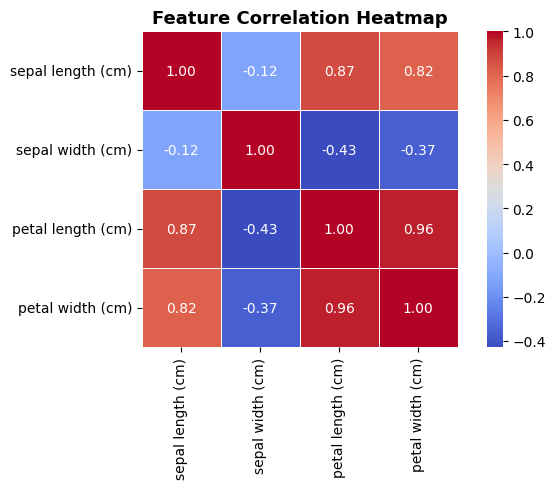

In [ ]:
# Corellation heatmap(-1 to 1)
plt.figure(figsize=(7, 5))
sns.heatmap(df[iris.feature_names].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
"""
K-Means Clustering — Core Idea
================================

K-Means is an UNSUPERVISED algorithm — no labels needed.
It groups data into K clusters based on similarity (distance).

Algorithm Steps:
  1. Randomly initialize K centroids
  2. Assign each point to the nearest centroid
  3. Recompute centroids as mean of all assigned points
  4. Repeat steps 2-3 until centroids stop moving (convergence)

Key difference from KNN:
  KNN     → supervised, needs labels, used for classification
  K-Means → unsupervised, no labels, used for grouping/clustering

Key Hyperparameter:
  K (number of clusters):
    Too small → merges distinct groups
    Too large → splits natural groups
"""
print(__doc__)

In [ ]:
# Preprocess — Scale Features (Drop Labels!)
X = df[iris.feature_names].values
y = df['species'].values  # only kept to evaluate at the end, NOT used in training

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Shape:", X_scaled.shape)
print("\nWe DROP labels during training — K-Means is unsupervised.")
print("Labels are only used at the end to evaluate cluster quality.")

"""
WHY SCALE?
  K-Means uses Euclidean distance to assign points to centroids.
  Features on larger scales dominate unfairly — same reason as KNN.
  StandardScaler → mean=0, std=1 for every feature.
"""

Shape: (150, 4)

We DROP labels during training — K-Means is unsupervised.
Labels are only used at the end to evaluate cluster quality.


'\nWHY SCALE?\n  K-Means uses Euclidean distance to assign points to centroids.\n  Features on larger scales dominate unfairly — same reason as KNN.\n  StandardScaler → mean=0, std=1 for every feature.\n'

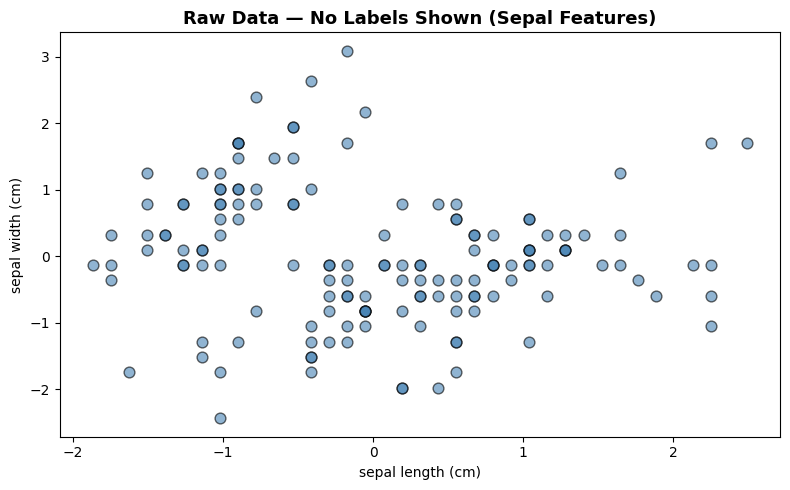

In [ ]:
## Raw data visualization
plt.figure(figsize=(8, 5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1],
            color='steelblue', alpha=0.6, edgecolors='k', s=60)
plt.title('Raw Data — No Labels Shown (Sepal Features)', fontsize=13, fontweight='bold')
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.tight_layout()
plt.show()

In [ ]:
#  K-Means From Scratch
class KMeans:
    """
    K-Means Clustering — from scratch.

    Parameters
    ----------
    k            : number of clusters
    max_iter     : maximum number of iterations
    tol          : convergence tolerance (min centroid shift to keep going)
    random_state : for reproducibility
    """

    def __init__(self, k=3, max_iter=100, tol=1e-4, random_state=42):
        self.k            = k
        self.max_iter     = max_iter
        self.tol          = tol
        self.random_state = random_state

    def fit(self, X):
        np.random.seed(self.random_state)
        X = np.array(X)

        # Step 1: Randomly pick K points as initial centroids
        random_idx     = np.random.choice(len(X), self.k, replace=False)
        self.centroids = X[random_idx].copy()
        self.history   = []  # store centroid positions each iteration

        for i in range(self.max_iter):
            # Step 2: Assign each point to nearest centroid
            labels = self._assign(X)

            # Step 3: Recompute centroids as mean of assigned points
            new_centroids = np.array([
                X[labels == j].mean(axis=0) for j in range(self.k)
            ])

            self.history.append(self.centroids.copy())

            # Step 4: Check convergence — how much did centroids move?
            shift = np.linalg.norm(new_centroids - self.centroids)
            self.centroids = new_centroids

            if shift < self.tol:
                print(f"  Converged at iteration {i+1}  (centroid shift={shift:.6f})")
                break

        self.labels_   = self._assign(X)
        self.inertia_  = self._inertia(X)
        return self

    def _assign(self, X):
        """Compute distance from each point to each centroid, assign to nearest."""
        distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)  # (n, k)
        return np.argmin(distances, axis=1)

    def _inertia(self, X):
        """WCSS — Within Cluster Sum of Squares."""
        total = 0
        for j in range(self.k):
            pts    = X[self.labels_ == j]
            total += np.sum((pts - self.centroids[j]) ** 2)
        return total

    def predict(self, X):
        return self._assign(np.array(X))

print("KMeans class defined!")

KMeans class defined!


In [ ]:
# Train & Evaluate the Model
kmeans = KMeans(k=3, random_state=42)
kmeans.fit(X_scaled)

print(f"\nInertia (WCSS) : {kmeans.inertia_:.4f}")
print(f"Cluster sizes  : {dict(zip(*np.unique(kmeans.labels_, return_counts=True)))}")


  Converged at iteration 7  (centroid shift=0.000000)

Inertia (WCSS) : 140.0328
Cluster sizes  : {np.int64(0): np.int64(56), np.int64(1): np.int64(50), np.int64(2): np.int64(44)}


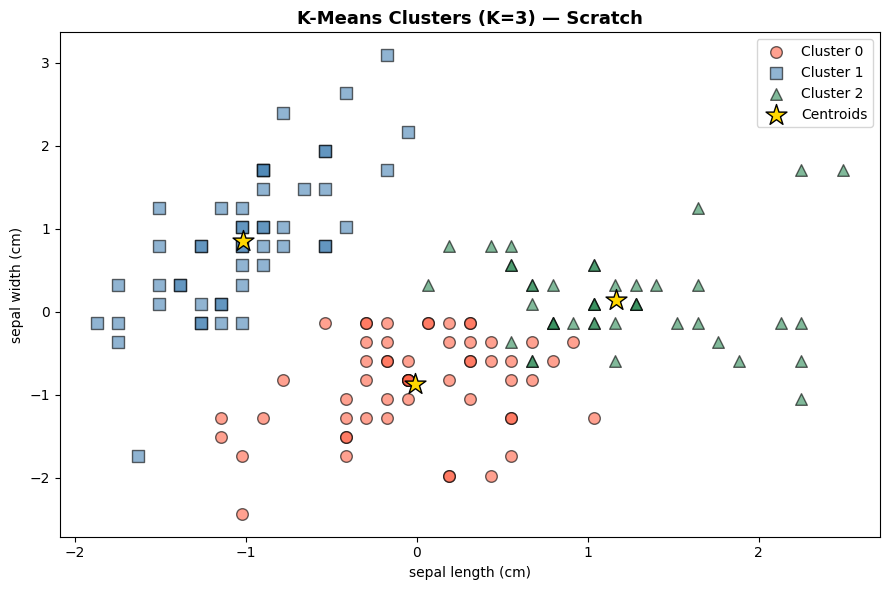

In [ ]:
# Visualize Clusters
colors  = ['tomato', 'steelblue', 'seagreen']
markers = ['o', 's', '^']

plt.figure(figsize=(9, 6))
for cluster in range(3):
    mask = kmeans.labels_ == cluster
    plt.scatter(X_scaled[mask, 0], X_scaled[mask, 1],
                color=colors[cluster], marker=markers[cluster],
                label=f'Cluster {cluster}', alpha=0.6, edgecolors='k', s=70)

plt.scatter(kmeans.centroids[:, 0], kmeans.centroids[:, 1],
            color='gold', s=250, marker='*', edgecolors='k',
            zorder=5, label='Centroids')

plt.title('K-Means Clusters (K=3) — Scratch', fontsize=13, fontweight='bold')
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.legend()
plt.tight_layout()
plt.show()

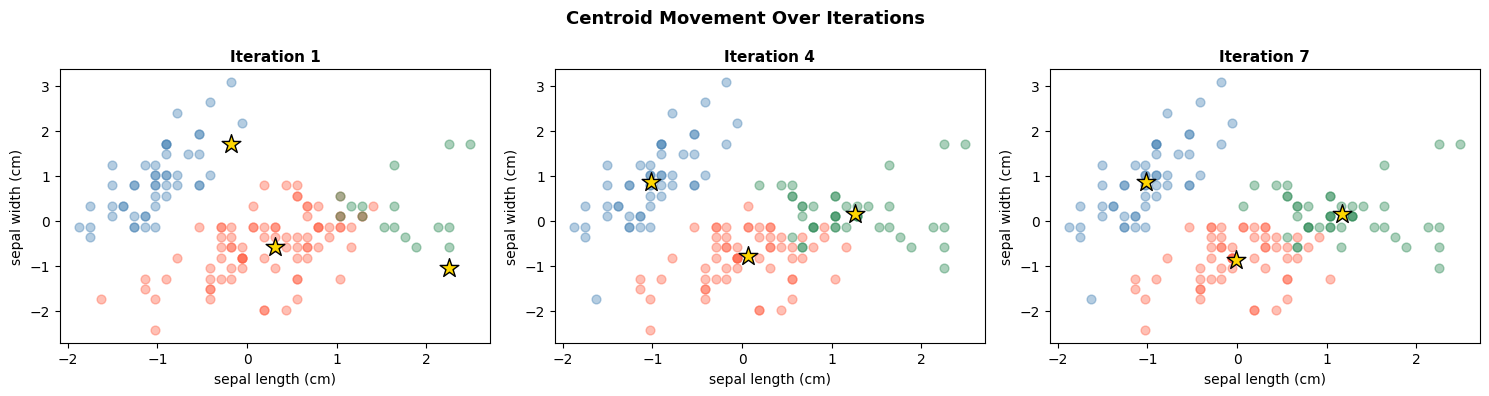

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
n         = len(kmeans.history)
steps     = [0, n // 2, n - 1]

for ax, step in zip(axes, steps):
    c_step  = kmeans.history[step]
    l_step  = np.argmin(np.linalg.norm(X_scaled[:, np.newaxis] - c_step, axis=2), axis=1)

    for cluster in range(3):
        mask = l_step == cluster
        ax.scatter(X_scaled[mask, 0], X_scaled[mask, 1],
                   color=colors[cluster], alpha=0.4, s=40)
    ax.scatter(c_step[:, 0], c_step[:, 1],
               color='gold', s=200, marker='*', edgecolors='k', zorder=5)
    ax.set_title(f'Iteration {step + 1}', fontsize=11, fontweight='bold')
    ax.set_xlabel(iris.feature_names[0])
    ax.set_ylabel(iris.feature_names[1])

plt.suptitle('Centroid Movement Over Iterations', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
ari = adjusted_rand_score(y, kmeans.labels_)
sil = silhouette_score(X_scaled, kmeans.labels_)

print(f"Adjusted Rand Index : {ari:.4f}  (1.0 = perfect match with true labels)")
print(f"Silhouette Score    : {sil:.4f}  (1.0 = perfect cluster separation)")

"""
Adjusted Rand Index (ARI):
  Compares our clusters to the true species labels.
  1.0 = perfect, 0.0 = random. Only usable when you HAVE ground truth.

Silhouette Score:
  Measures how similar a point is to its own cluster vs other clusters.
  Range: -1 to 1. Higher is better. Usable WITHOUT ground truth labels.
  This is what you use in real-world problems where you have no labels.
"""


Adjusted Rand Index : 0.5923  (1.0 = perfect match with true labels)
Silhouette Score    : 0.4630  (1.0 = perfect cluster separation)


'\nAdjusted Rand Index (ARI):\n  Compares our clusters to the true species labels.\n  1.0 = perfect, 0.0 = random. Only usable when you HAVE ground truth.\n\nSilhouette Score:\n  Measures how similar a point is to its own cluster vs other clusters.\n  Range: -1 to 1. Higher is better. Usable WITHOUT ground truth labels.\n  This is what you use in real-world problems where you have no labels.\n'

  Converged at iteration 2  (centroid shift=0.000000)
  Converged at iteration 3  (centroid shift=0.000000)
  Converged at iteration 7  (centroid shift=0.000000)
  Converged at iteration 10  (centroid shift=0.000000)
  Converged at iteration 7  (centroid shift=0.000000)
  Converged at iteration 9  (centroid shift=0.000000)
  Converged at iteration 7  (centroid shift=0.000000)
  Converged at iteration 8  (centroid shift=0.000000)
  Converged at iteration 8  (centroid shift=0.000000)
  Converged at iteration 9  (centroid shift=0.000000)


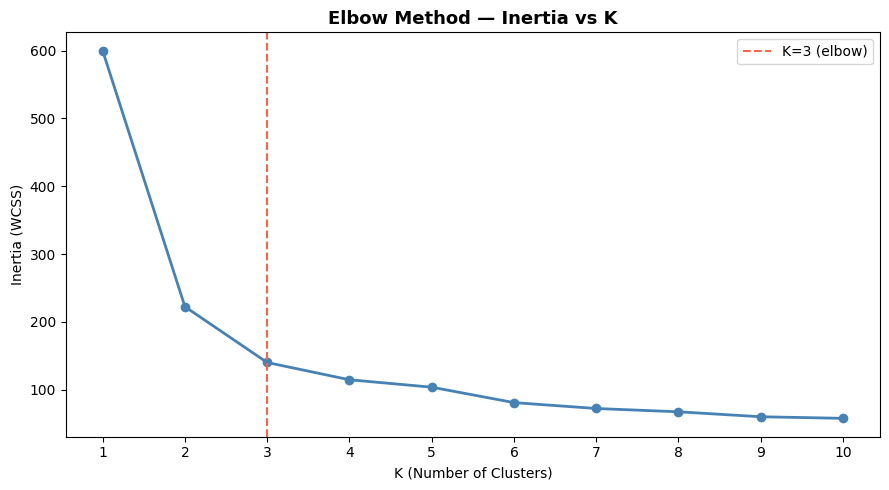

In [ ]:
## Elbow method for choosing k
"""
WCSS (Inertia) always decreases as K increases.
The "elbow" is where the rate of decrease slows sharply.
That K is the sweet spot — adding more clusters gives diminishing returns.
"""

k_values = range(1, 11)
inertias = []

for k in k_values:
    m = KMeans(k=k, random_state=42)
    m.fit(X_scaled)
    inertias.append(m.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(k_values, inertias, marker='o', color='steelblue', linewidth=2)
plt.axvline(x=3, linestyle='--', color='tomato', label='K=3 (elbow)')
plt.title('Elbow Method — Inertia vs K', fontsize=13, fontweight='bold')
plt.xlabel('K (Number of Clusters)')
plt.ylabel('Inertia (WCSS)')
plt.xticks(k_values)
plt.legend()
plt.tight_layout()
plt.show()



## KMeans using Library


In [ ]:
from sklearn.cluster import KMeans as SKLearnKMeans


In [ ]:
#  Train
kmeans_sk = SKLearnKMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_sk.fit(X_scaled)

KMeans(n_clusters=3, n_init=10, random_state=42)

In [ ]:
ari_sk = adjusted_rand_score(y, kmeans_sk.labels_)
sil_sk = silhouette_score(X_scaled, kmeans_sk.labels_)

print(f"Sklearn — Inertia            : {kmeans_sk.inertia_:.4f}")
print(f"Sklearn — Adjusted Rand Index: {ari_sk:.4f}")
print(f"Sklearn — Silhouette Score   : {sil_sk:.4f}")

Sklearn — Inertia            : 139.8205
Sklearn — Adjusted Rand Index: 0.6201
Sklearn — Silhouette Score   : 0.4599


In [ ]:
summary = pd.DataFrame({
    'Model'          : ['K-Means Scratch', 'K-Means Sklearn'],
    'Inertia'        : [round(kmeans.inertia_, 4), round(kmeans_sk.inertia_, 4)],
    'ARI'            : [round(ari, 4),             round(ari_sk, 4)],
    'Silhouette'     : [round(sil, 4),             round(sil_sk, 4)],
})
print(summary.to_string(index=False))

"""
WHY might Sklearn score slightly better?

  n_init=10 → Sklearn runs K-Means 10 times with different random starts
              and picks the best result (lowest inertia).
  Our scratch version runs only once, so it may get unlucky with initialization.

  In real use, always use n_init > 1 to avoid bad random initializations.
"""


          Model  Inertia    ARI  Silhouette
K-Means Scratch 140.0328 0.5923      0.4630
K-Means Sklearn 139.8205 0.6201      0.4599


'\nWHY might Sklearn score slightly better?\n\n  n_init=10 → Sklearn runs K-Means 10 times with different random starts\n              and picks the best result (lowest inertia).\n  Our scratch version runs only once, so it may get unlucky with initialization.\n\n  In real use, always use n_init > 1 to avoid bad random initializations.\n'

In [ ]:
"""
K-Means — Summary
==================

PROS:
  ✅ Simple and fast — O(n * k * iterations)
  ✅ Scales well to large datasets
  ✅ Easy to interpret

CONS:
  ❌ Must specify K upfront
  ❌ Sensitive to random initialization (use n_init > 1)
  ❌ Assumes clusters are spherical and equal-sized
  ❌ Sensitive to outliers (mean gets pulled)
  ❌ Struggles with non-globular cluster shapes
"""
print(__doc__)


K-Means — Summary

PROS:
  ✅ Simple and fast — O(n * k * iterations)
  ✅ Scales well to large datasets
  ✅ Easy to interpret

CONS:
  ❌ Must specify K upfront
  ❌ Sensitive to random initialization (use n_init > 1)
  ❌ Assumes clusters are spherical and equal-sized
  ❌ Sensitive to outliers (mean gets pulled)
  ❌ Struggles with non-globular cluster shapes

